In [9]:
from __future__ import print_function 
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import random
from sklearn.datasets import fetch_openml
import os
import struct
from mnist.loader import MNIST
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
import time

In [10]:
!pip install python-mnist


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: C:\Users\Ashura\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [11]:
mndata = MNIST('MNIST')
images, labels = mndata.load_training()
list_labels = list(labels)
def plot_image_index(list_labels, images, labels, number):
    plt.figure(figsize=(12, 6))
    labels_index = []
    for i in range(number):
        labels_index.append(list_labels.index(i))
        image_2d  = np.array(images[list_labels.index(i)]).reshape(28,28)
        plt.subplot(2, 5, i + 1)
        plt.imshow(image_2d, cmap='gray')
        plt.title(f"Index: {i} \nLabel: {labels[list_labels.index(i)]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def label_index(list_labels):
    labels_index = []
    for i in range(10):
        labels_index.append(list_labels.index(i))
    return labels_index

label_index = label_index(list_labels)

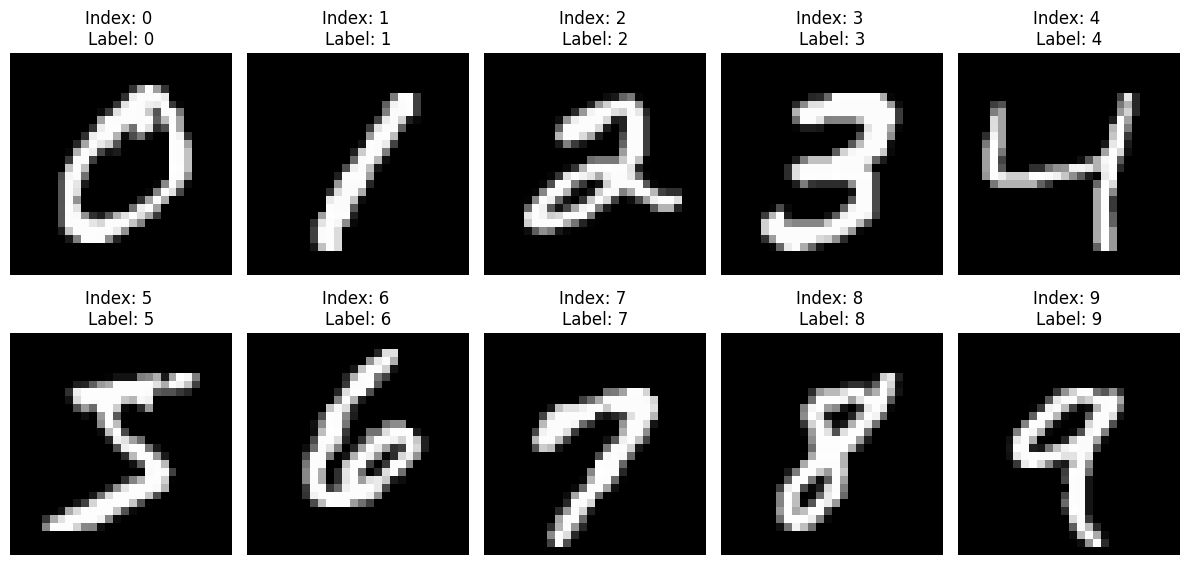

255


In [12]:
plot_image_index(list_labels, images, labels, 10)
print(np.max(images))

In [13]:
X_raw = np.array(images, dtype=float)
Y = np.array(labels)

print("Đã tải thành công tập dữ liệu huấn luyện!")
print("Kích thước mảng ảnh thô:", X_raw.shape)
images, labels = mndata.load_training()



Đã tải thành công tập dữ liệu huấn luyện!
Kích thước mảng ảnh thô: (60000, 784)


In [14]:
# Giảm chiều ma trận
X_flatten = X_raw.reshape(X_raw.shape[0], -1)

# Chuẩn hóa dữ liệu (kiếm google)
from sklearn.preprocessing import normalize
X = normalize(X_flatten, norm='l2')
print(type(X))
print(type(Y))
print(X.shape)
print(Y.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(60000, 784)
(60000,)


In [15]:
def label_to_onehot(Y):
    K = max(Y) + 1
    N = len(Y)
    result = np.zeros((N,K))
    for i in range(len(Y)):
        result[i][Y[i]] = 1
    return result

Y = label_to_onehot(Y)
print(Y)

[[0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]]


In [16]:
def relu(z): 
    return np.maximum(0,z)

def softmax(z):
    return np.exp(z)/np.sum(np.exp(z))

In [20]:
d = [784, 512, 128, 32, 10]
def feed_forward(X, W, b, d):
    """
    input:
    X: features (784,N)
    W: tập hợp L m trận
    L1 = 512, L2 = 128, L3 = 32, L4 = 10
    f2 = ReLu, f3 = ReLU, f4 = ReLu, f5 = Softmax
    """
    A = []
    Z = []
    a = X
    A.append(a)
    z = np.dot(W[0].T,a)
    for layer in range(1, len(d)-1):
        a = relu(z)
        A.append(a)
        z = np.dot(W[layer].T,a) + b[layer]
        Z.append(z)
        print("shape of a:", a.shape)
    a_L = softmax(z)
    A.append(a_L)
    return a_L, A, Z

W = [
    np.random.uniform(0, 0.1, size=(784,512)),
    np.random.uniform(0, 0.1, size=(512,128)),
    np.random.uniform(0, 0.1, size=(128,32)),
    np.random.uniform(0, 0.1, size=(32,10)),
    ]

b = [np.zeros((d[i+1], 1)) for i in range(len(d)-1)]
y_hat, A, Z = feed_forward(X.T, W, b, [784, 512, 128, 32, 10])
print(y_hat.shape)
print(A)

shape of a: (512, 60000)
shape of a: (128, 60000)
shape of a: (32, 60000)
(10, 60000)
[array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(784, 60000)), array([[0.56492204, 0.61286445, 0.4980448 , ..., 0.52803513, 0.46810148,
        0.49940089],
       [0.54263128, 0.59351708, 0.51380102, ..., 0.52891903, 0.51505936,
        0.50779727],
       [0.56618849, 0.61752635, 0.53752532, ..., 0.53205821, 0.52586474,
        0.51465405],
       ...,
       [0.5539698 , 0.57702775, 0.47307778, ..., 0.49790791, 0.49845404,
        0.51185402],
       [0.54129153, 0.63375688, 0.55644887, ..., 0.52500009, 0.54871289,
        0.52697826],
       [0.5531315 , 0.58887685, 0.49603241, ..., 0.53351097, 0.523813  ,
        0.51549872]], shape=(512, 60000)), array([[15.02085701, 15.91416564, 13.17770488, ..., 1

In [21]:
def calculate_loss(Y, Y_hat, epsilon=1e-10):
    N = Y.shape[1]
    return -np.sum(Y * np.log(Y_hat + epsilon)) / N
print(Y.shape)
J = calculate_loss(Y.T, y_hat, epsilon=1e-10)

(60000, 10)


In [22]:
print(A)

[array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(784, 60000)), array([[0.56492204, 0.61286445, 0.4980448 , ..., 0.52803513, 0.46810148,
        0.49940089],
       [0.54263128, 0.59351708, 0.51380102, ..., 0.52891903, 0.51505936,
        0.50779727],
       [0.56618849, 0.61752635, 0.53752532, ..., 0.53205821, 0.52586474,
        0.51465405],
       ...,
       [0.5539698 , 0.57702775, 0.47307778, ..., 0.49790791, 0.49845404,
        0.51185402],
       [0.54129153, 0.63375688, 0.55644887, ..., 0.52500009, 0.54871289,
        0.52697826],
       [0.5531315 , 0.58887685, 0.49603241, ..., 0.53351097, 0.523813  ,
        0.51549872]], shape=(512, 60000)), array([[15.02085701, 15.91416564, 13.17770488, ..., 13.67079516,
        13.56765849, 13.68539218],
       [13.78140723, 14.59268306, 12.06

In [23]:
print(Z)

[array([[15.02085701, 15.91416564, 13.17770488, ..., 13.67079516,
        13.56765849, 13.68539218],
       [13.78140723, 14.59268306, 12.066555  , ..., 12.54004843,
        12.43227915, 12.53898596],
       [14.41074079, 15.25533927, 12.60388465, ..., 13.08471732,
        12.99863444, 13.11614487],
       ...,
       [14.01901054, 14.84190489, 12.30469385, ..., 12.74929284,
        12.67214997, 12.78019768],
       [14.65086451, 15.51289015, 12.85964526, ..., 13.34118249,
        13.26054913, 13.33420998],
       [14.63104297, 15.48686439, 12.82926546, ..., 13.26542003,
        13.18040195, 13.3118799 ]], shape=(128, 60000)), array([[ 91.40419931,  96.76939496,  80.13895695, ...,  83.09926352,
         82.49355576,  83.18777602],
       [ 89.85132553,  95.12973119,  78.790582  , ...,  81.69385369,
         81.09725817,  81.78149146],
       [ 95.16572629, 100.75144051,  83.43458216, ...,  86.52430576,
         85.89108682,  86.61162019],
       ...,
       [101.76779696, 107.75142514,

In [26]:
def backpropagation(J, W, A, y, Z):
    """
    SGD
    input: J, w, A, b 
    - J: lossfunction (float)
    - W: list(4 matrix)
    - A: list(4 vector)
    - b: list(4 vector bias)
    Output: gradient_w list (đạo hàm của J theo W từng layer)
            gradient_b list (đạo hàm của J theo b từng layer)

        dJ/dW_L = a_L-1 . (a_L - y)
        dJ/dB_L = a_L-y
        e_l = (W_l+1.e_l+1) * f'(z_l)
        dJ/dW_l = a_l-1 . e_l.T
        dJ/db_l = e_l
        
    """
    gradient_W = []
    gradient_b = []
    e_l = A[-1] - y
    for l in range(len(A), 0, -1):
        gradient_W.append(np.dot(A[l-1], e_l))
        gradient_b.append(e_l)

        e_l = np.dot(W[l], e_l) & np.astype(Z[l-1], np.int8)
        # e_3 = (W_4 * e_4) * f'(z_3)_(đạo hàm của ReLU)
    
backpropagation(J, W, A, Y[0], Z)
# Dùng onehot cho Y


ValueError: operands could not be broadcast together with shapes (10,60000) (10,) 

In [29]:
print(Y[:,].shape)

(60000, 10)


In [ ]:
a = np.array([[1,2,3],
             [-4,0,-6]])
print(a>0)
np.astype(a > 0, np.int8)

[[ True  True  True]
 [False False False]]


array([[1, 1, 1],
       [0, 0, 0]], dtype=int8)

In [ ]:
def onehot_to_label(Y):
    label = []
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]): 
            if Y[i,j] == 1:
                label.append(j)
    return np.array(label)

label_after_predict = onehot_to_label(Y)
print(label_after_predict)
print(M)

[5 0 4 ... 5 6 8]


NameError: name 'M' is not defined